In [ ]:
import os, sys, yaml
from dataclasses import dataclass
from itertools import combinations_with_replacement
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = next(parent for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (parent / "config.yaml").exists())
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.metrics_comparison import layer_distance_comparison_save_name


In [21]:
@dataclass
class Cfg:
    folder_name: str = "talia_20each_tizi"
    model_name: str = "vit_l_16"
    img_size: int = 384
    k: int = 1
    metric_A: str = "cosine_cnt"
    metric_B: str = "cosine"
    subsamples_size: int | None = None
    n_iterations: int | None = None
    cmap_name: str = "viridis"
    vmin: float | None = None
    vmax: float | None = None
    figsize: tuple[float, float] = (18, 6)


cfg = Cfg()
cfg


Cfg(folder_name='talia_20each_tizi', model_name='vit_l_16', img_size=384, k=1, metric_A='cosine_cnt', metric_B='cosine', subsamples_size=None, n_iterations=None, cmap_name='viridis', vmin=None, vmax=None, figsize=(18, 6))

In [22]:
def layer_distance_path(direction, metric_A=None, metric_B=None):
    return Path(
        layer_distance_comparison_save_name(
            paths,
            direction,
            metric_A or cfg.metric_A,
            metric_B or cfg.metric_B,
            cfg.k,
            cfg.folder_name,
            cfg.model_name,
            cfg.img_size,
            subsamples_size=cfg.subsamples_size,
            n_iterations=cfg.n_iterations,
        )
    )


def load_layer_distance_pair(metric_A=None, metric_B=None):
    metric_A = metric_A or cfg.metric_A
    metric_B = metric_B or cfg.metric_B

    def pair_paths(metric_from, metric_to):
        return (
            layer_distance_path("A2B", metric_from, metric_to),
            layer_distance_path("B2A", metric_from, metric_to),
        )

    fn_A2B, fn_B2A = pair_paths(metric_A, metric_B)
    try:
        if not fn_A2B.exists() or not fn_B2A.exists():
            raise FileNotFoundError
    except FileNotFoundError:
        swapped_A2B, swapped_B2A = pair_paths(metric_B, metric_A)
        if swapped_A2B.exists() and swapped_B2A.exists():
            fn_A2B, fn_B2A = swapped_A2B, swapped_B2A
        else:
            missing = [str(fn) for fn in (fn_A2B, fn_B2A, swapped_A2B, swapped_B2A) if not fn.exists()]
            raise FileNotFoundError("Missing layer-distance matrix files:\n" + "\n".join(missing))

    data_A2B = np.load(fn_A2B)
    data_B2A = np.load(fn_B2A)
    return {
        "A2B": data_A2B["arr_0"],
        "B2A": data_B2A["arr_0"],
        "layers": data_A2B["layers"].astype(str),
        "metrics": data_A2B["metrics"].astype(str),
        "paths": {"A2B": fn_A2B, "B2A": fn_B2A},
    }


def plot_layer_distance_pair(metric_A=None, metric_B=None, cmap_name=None, vmin=None, vmax=None):
    result = load_layer_distance_pair(metric_A, metric_B)
    A2B = result["A2B"]
    B2A = result["B2A"]
    layers = result["layers"]
    metric_A, metric_B = result["metrics"]

    if vmin is None:
        vmin = cfg.vmin if cfg.vmin is not None else np.nanmin([np.nanmin(A2B), np.nanmin(B2A)])
    if vmax is None:
        vmax = cfg.vmax if cfg.vmax is not None else np.nanmax([np.nanmax(A2B), np.nanmax(B2A)])
    cmap_name = cmap_name or cfg.cmap_name

    fig, axes = plt.subplots(1, 3, figsize=cfg.figsize, constrained_layout=True)
    matrix_axes = axes[:2]
    for ax, mat, direction in zip(matrix_axes, (A2B, B2A), ("A2B", "B2A")):
        im = ax.imshow(mat, cmap=cmap_name, vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(f"{direction} | {metric_A}-{metric_B} | k={cfg.k}")
        ax.set_xlabel("Layer B")
        ax.set_ylabel("Layer A")
        ax.set_xticks(np.arange(len(layers)))
        ax.set_yticks(np.arange(len(layers)))
        ax.set_xticklabels(layers, rotation=90)
        ax.set_yticklabels(layers)

    depth = np.arange(len(layers))
    ax = axes[2]
    ax.plot(depth, np.diag(A2B), marker="o", label="A2B")
    ax.plot(depth, np.diag(B2A), marker="o", label="B2A")
    ax.set_title("Diagonal by layer depth")
    ax.set_xlabel("Layer depth")
    ax.set_ylabel("Information Imbalance")
    ax.set_xticks(depth)
    ax.set_xticklabels(layers, rotation=90)
    ax.set_ylim(vmin, vmax)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)

    fig.colorbar(im, ax=matrix_axes, shrink=0.85, label="Information Imbalance")
    return fig, axes, result


/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_cosine-cosine_cnt_talia_20each_tizi_vit_l_16_384.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_cosine-cosine_cnt_talia_20each_tizi_vit_l_16_384.npz


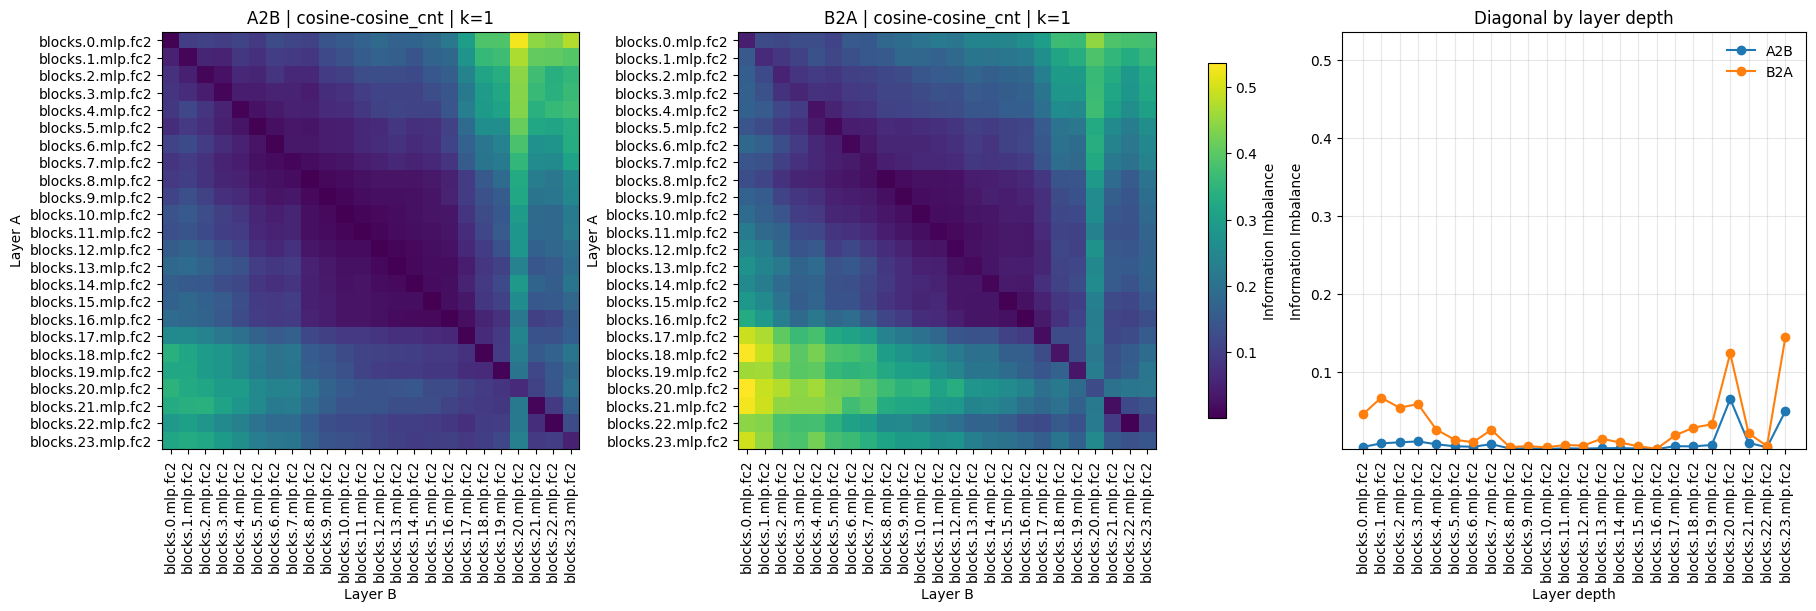

In [23]:
fig, axes, result = plot_layer_distance_pair()
print(result["paths"]["A2B"])
print(result["paths"]["B2A"])


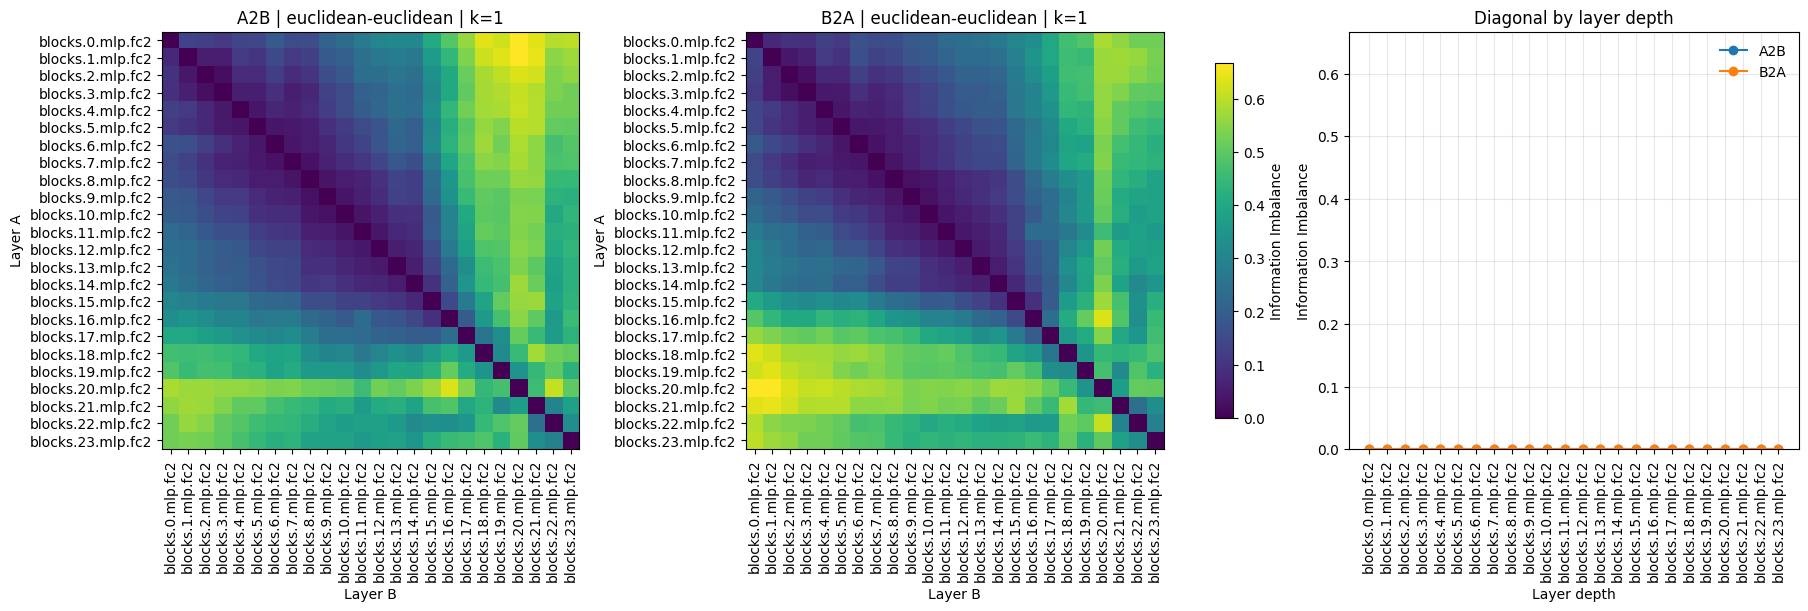

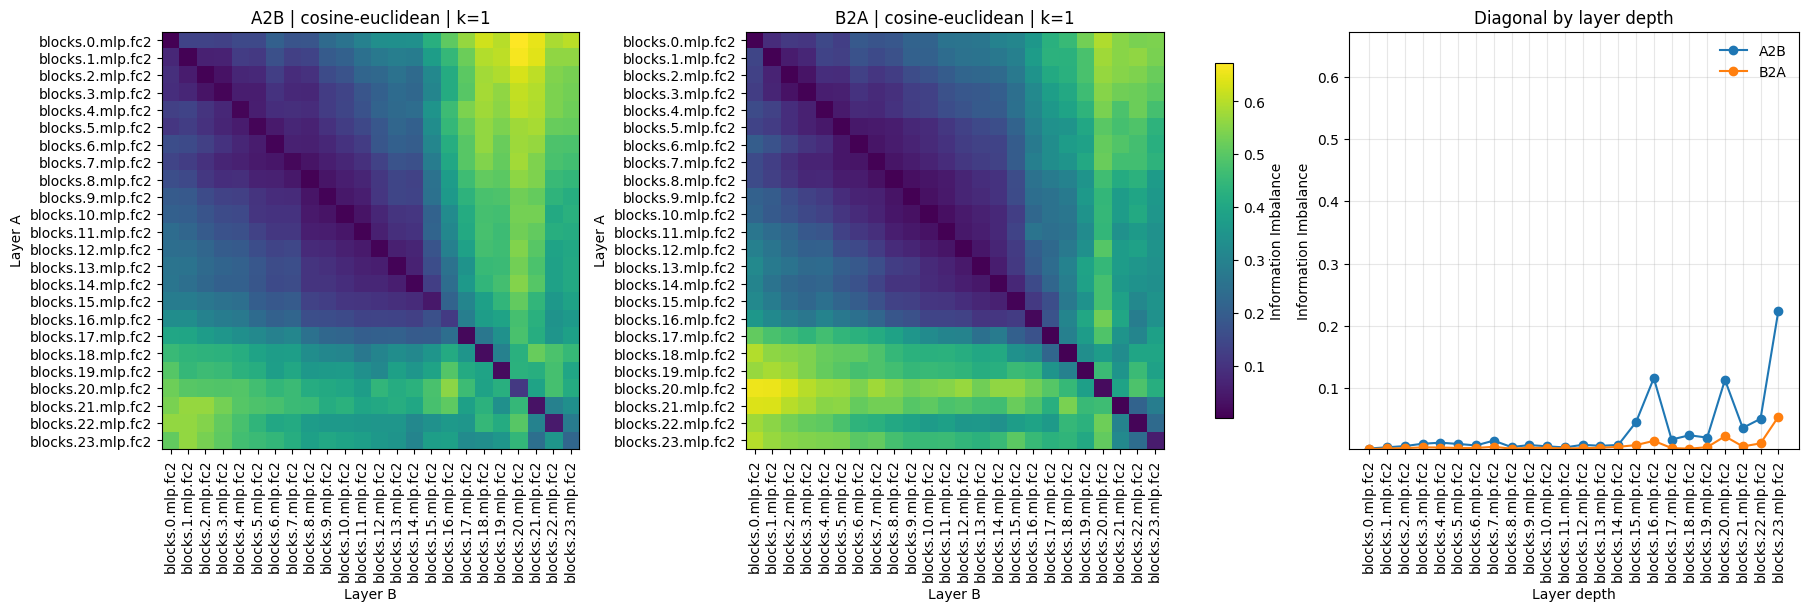

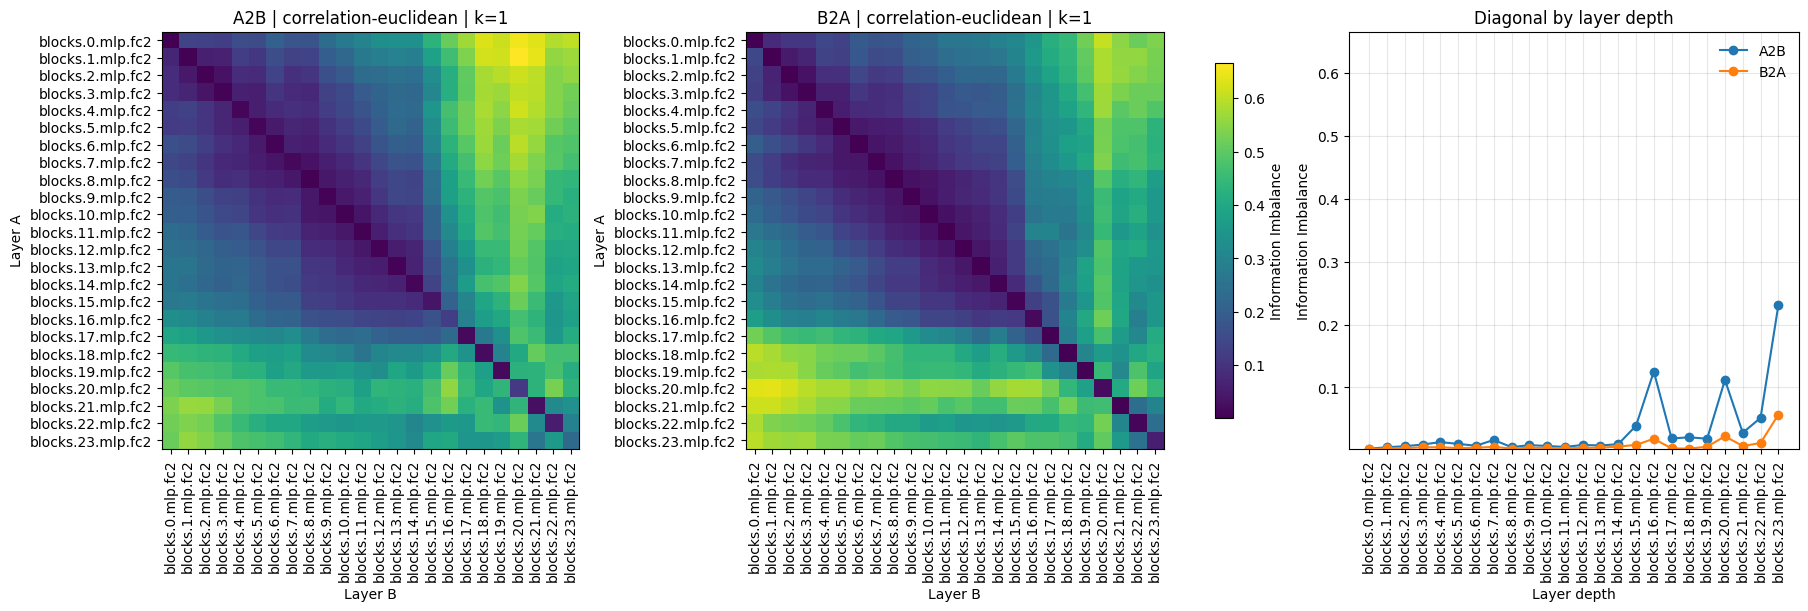

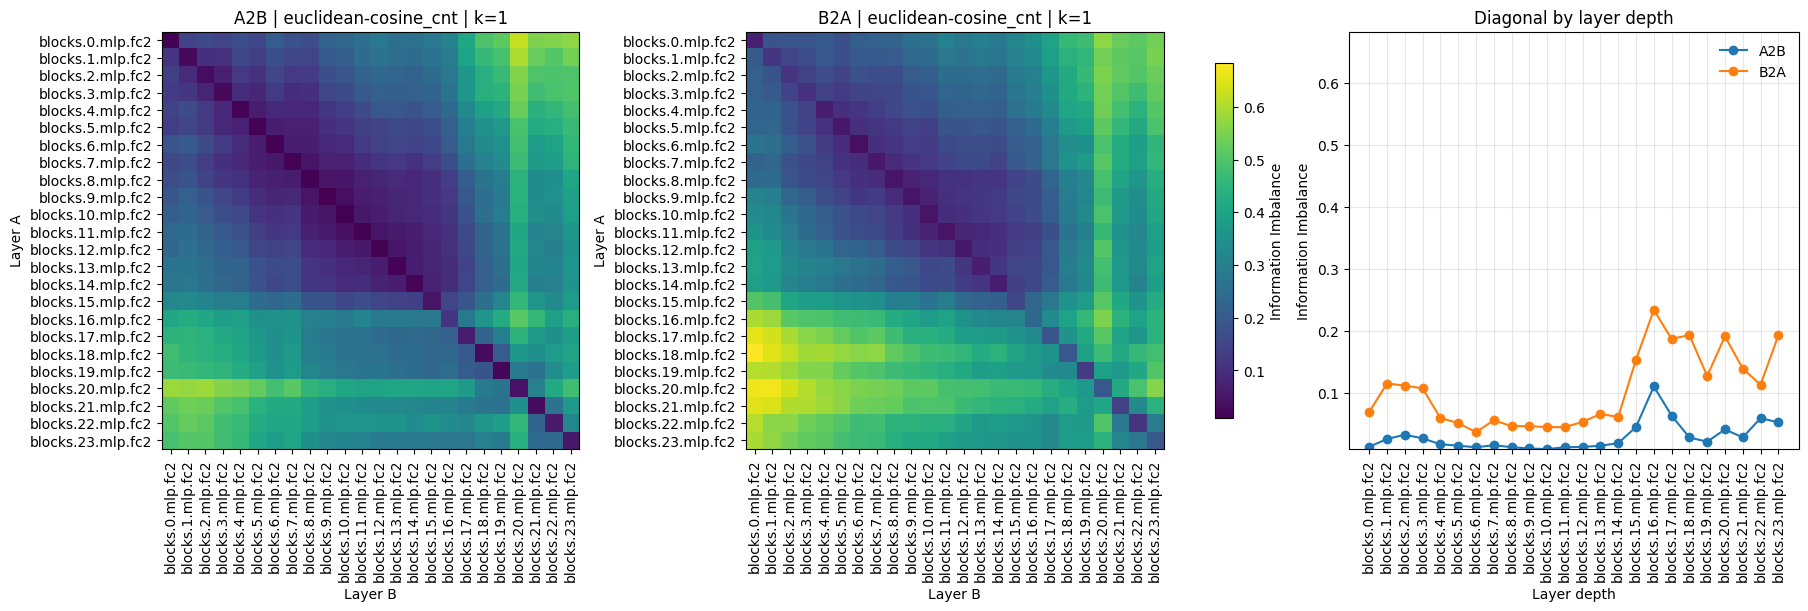

Missing layer-distance matrix files:
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_euclidean-magnitude_diff_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_euclidean-magnitude_diff_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_magnitude_diff-euclidean_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_magnitude_diff-euclidean_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz


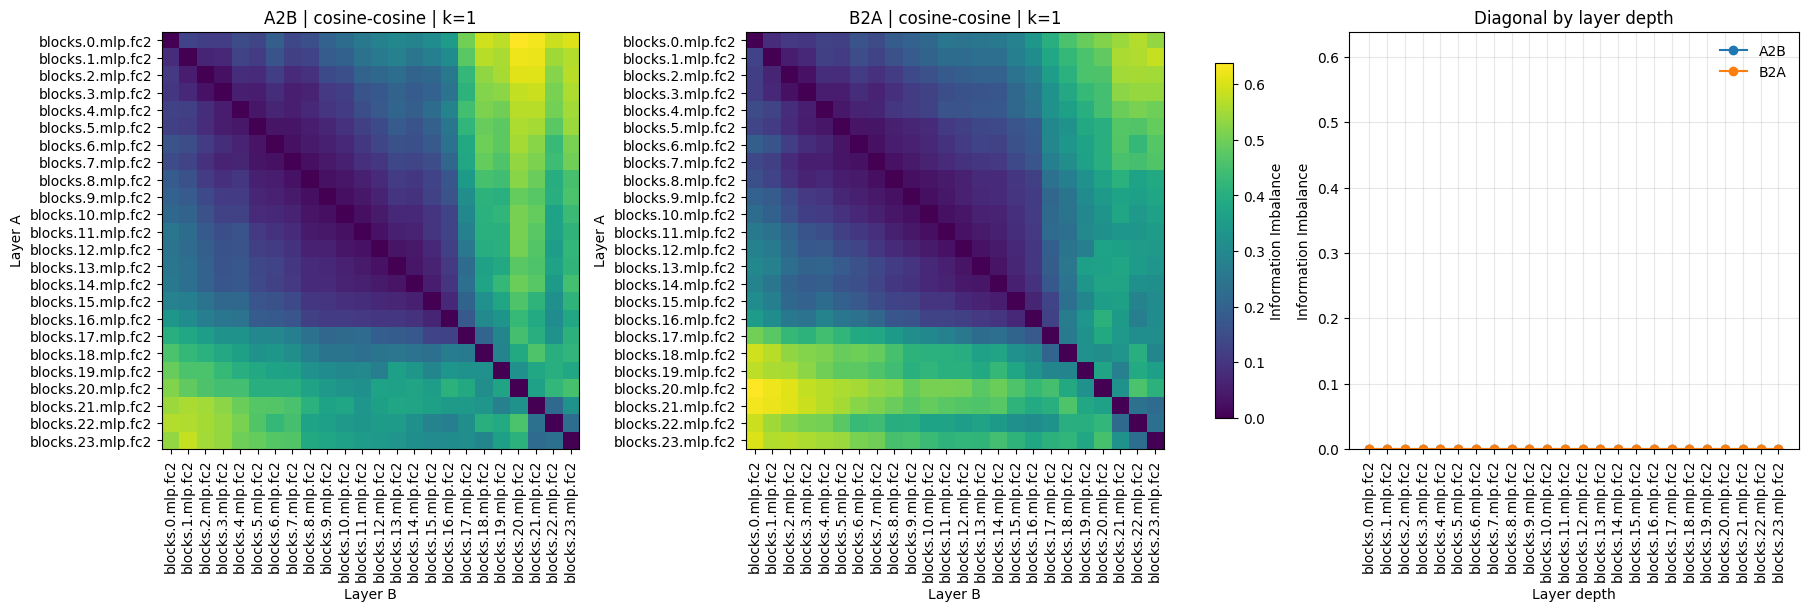

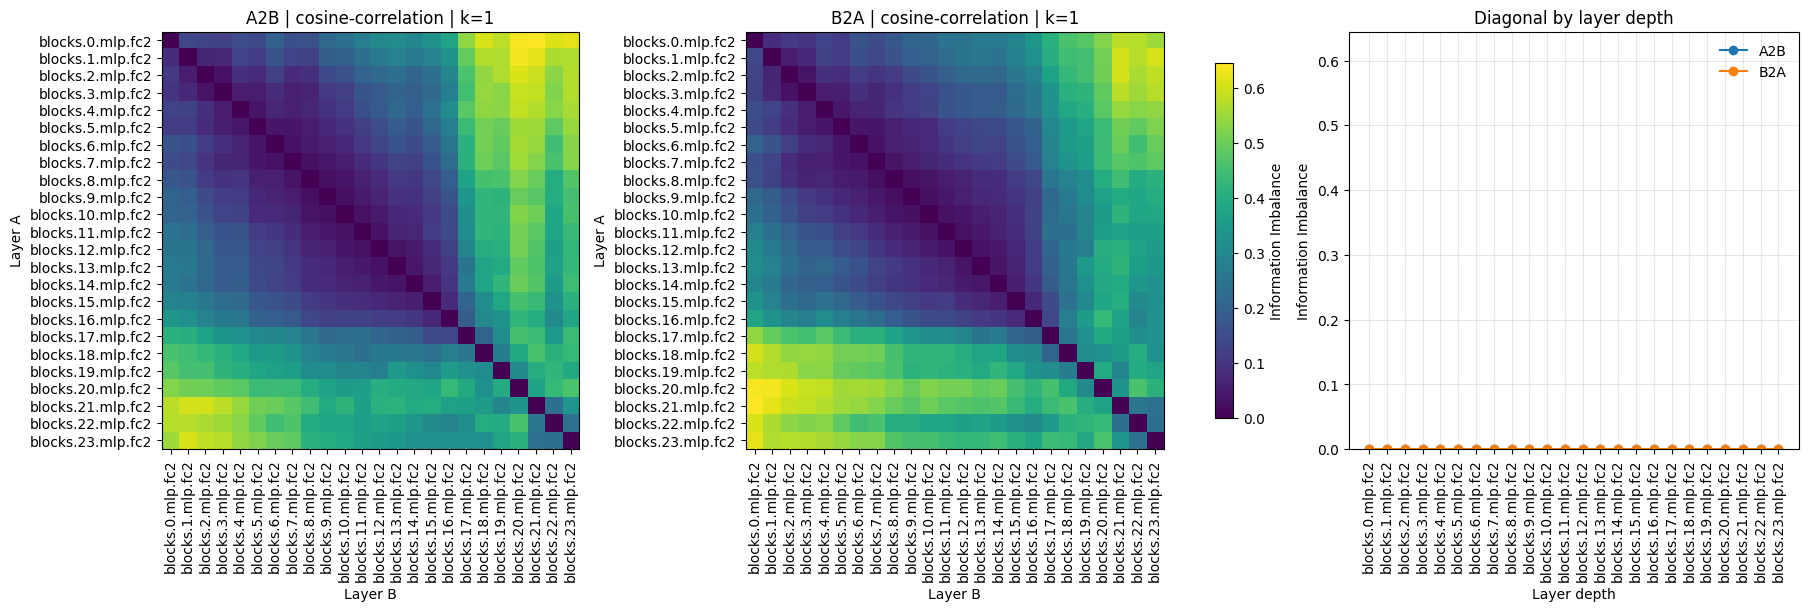

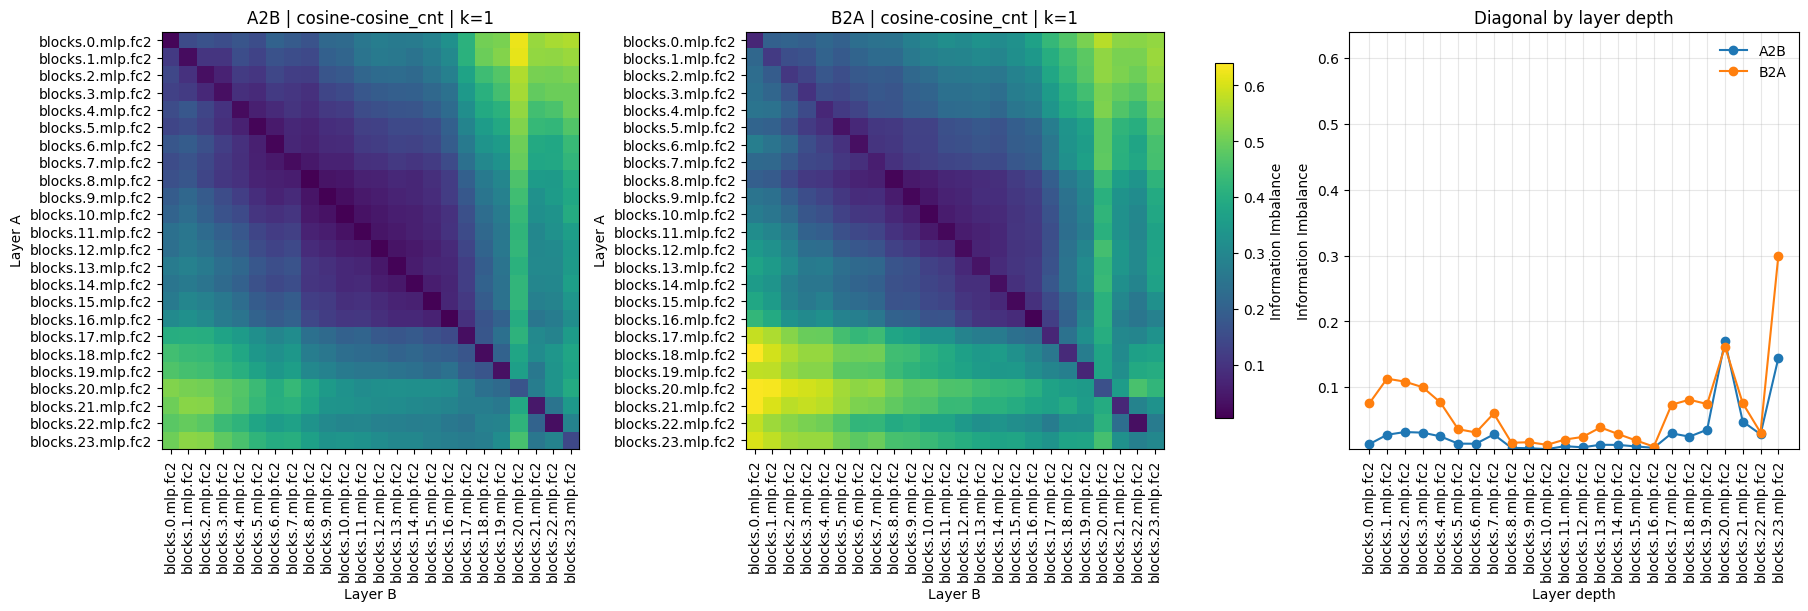

Missing layer-distance matrix files:
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_cosine-magnitude_diff_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_cosine-magnitude_diff_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_magnitude_diff-cosine_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_magnitude_diff-cosine_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz


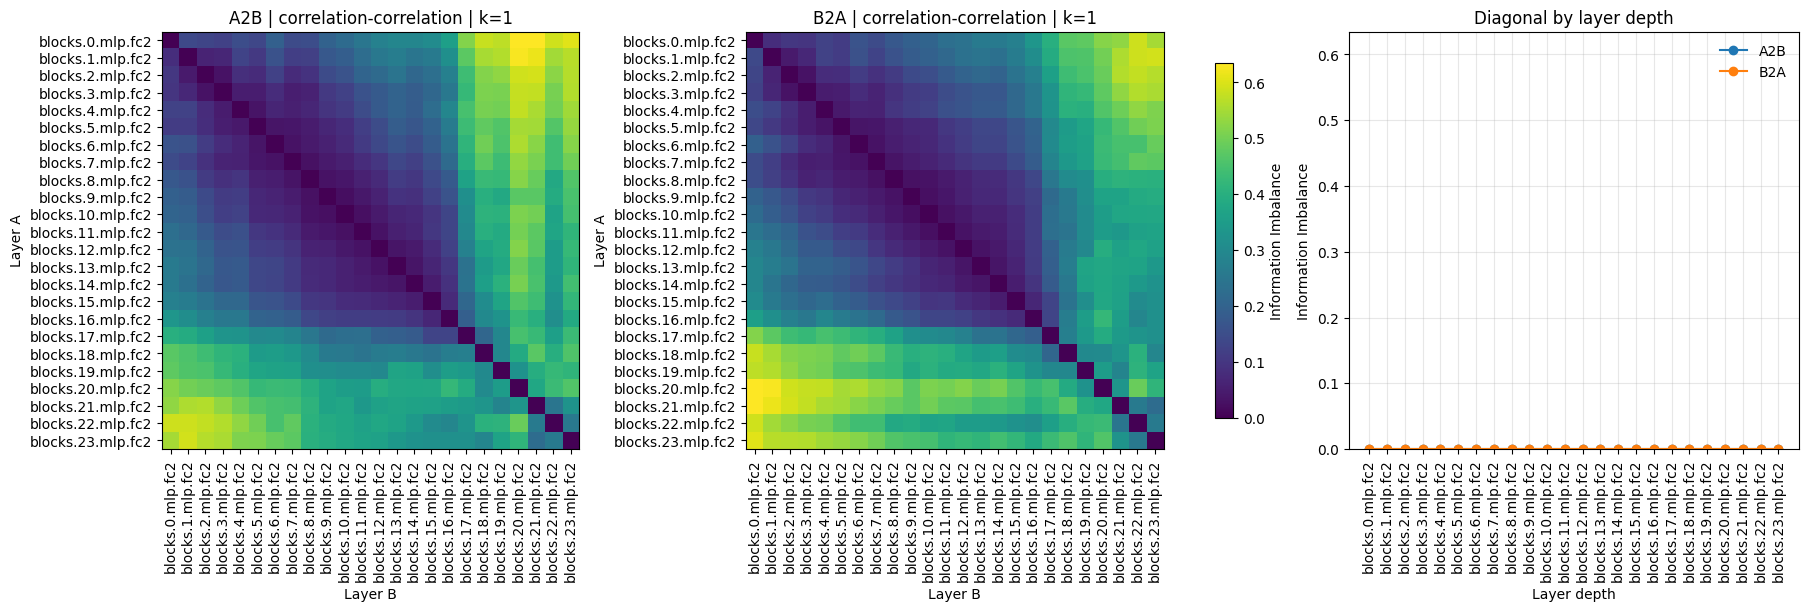

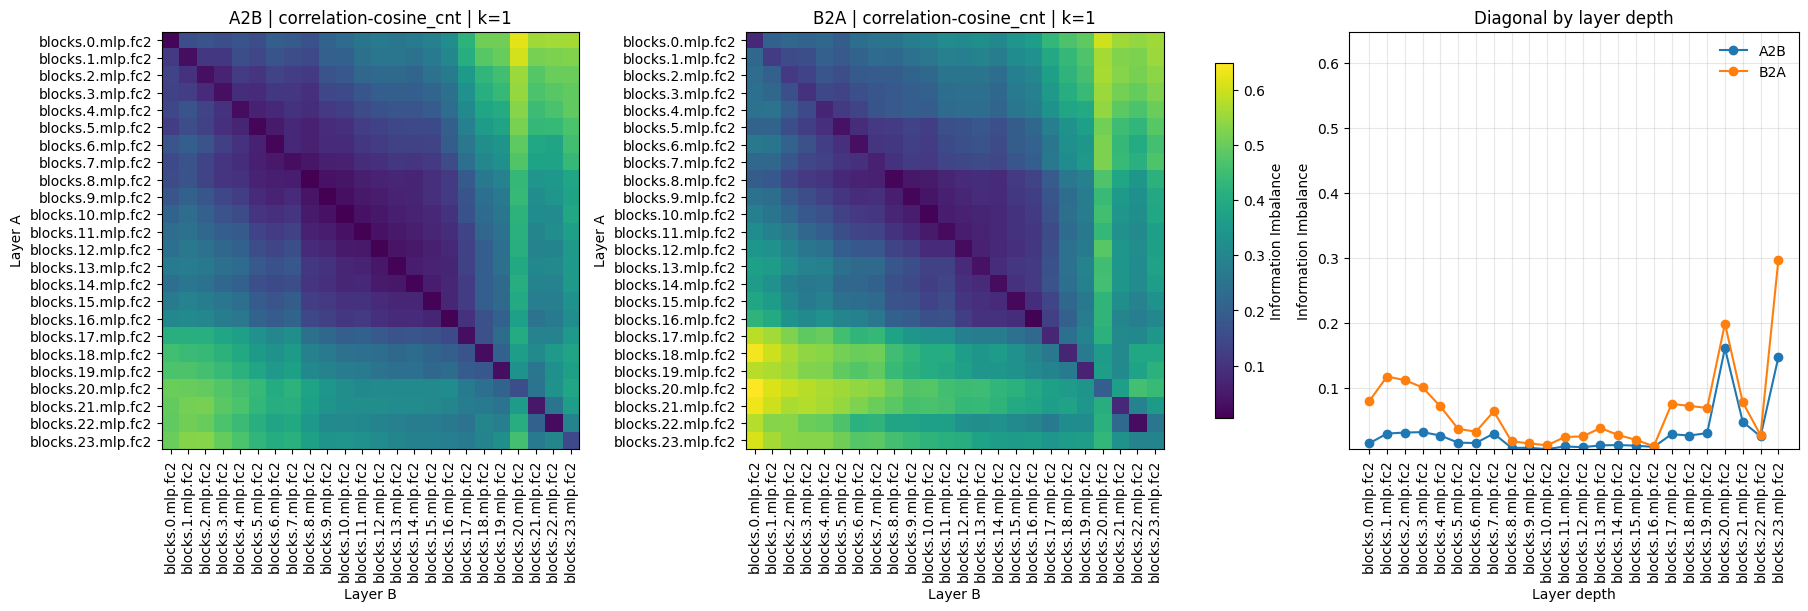

Missing layer-distance matrix files:
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_correlation-magnitude_diff_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_correlation-magnitude_diff_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_magnitude_diff-correlation_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_magnitude_diff-correlation_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz


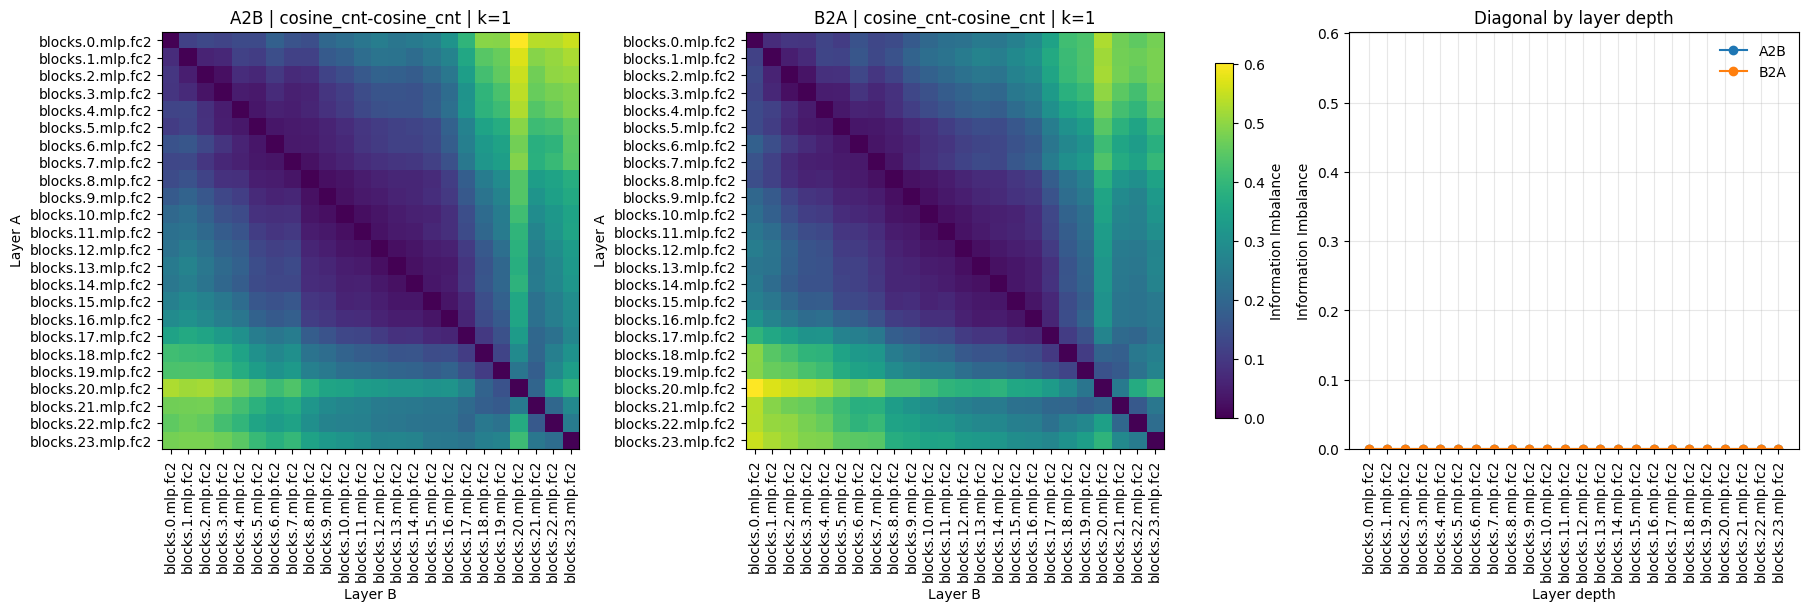

Missing layer-distance matrix files:
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_cosine_cnt-magnitude_diff_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_cosine_cnt-magnitude_diff_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_magnitude_diff-cosine_cnt_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_magnitude_diff-cosine_cnt_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
Missing layer-distance matrix files:
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_A2B_k1_magnitude_diff-magnitude_diff_talia_20each_tizi_vit_l_16_384_200subsamples_20iterations.npz
/Users/tizianocausin/metrics_II_local/results/layer_distance_comparison_B2A_k1_magnitud

In [20]:
metrics = ("euclidean", "cosine", "correlation", "cosine_cnt", "magnitude_diff")
for metric_A, metric_B in combinations_with_replacement(metrics, 2):
    try:
        plot_layer_distance_pair(metric_A, metric_B)
        plt.show()
    except FileNotFoundError as exc:
        print(exc)
